# Rock-Paper-Scissors Classification with Teachable Machine

This notebook demonstrates the implementation of a Rock-Paper-Scissors classifier using a model trained with Teachable Machine. The classification is performed on both static images and live webcam feed. 

## Table of Contents
1. [Installation](#installation)
2. [Importing Libraries](#importing-libraries)
3. [Loading the Model and Labels](#loading-the-model-and-labels)
4. [Image Classification](#image-classification)
5. [Live Classification with Webcam](#live-classification-with-webcam)

## Installation

Ensure you have the following libraries installed in your environment:

```bash
pip install tensorflow==2.12.1 opencv-python matplotlib pillow


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import load_model
from PIL import Image, ImageOps


## Load the trained model from Teachable Machine


In [4]:
# Load the trained model from Teachable Machine
model = load_model(r'C:\Users\Risha\OneDrive\Desktop\05\model\keras_model.h5', compile=False)

# Load class names from labels.txt
def load_labels(label_file):
    with open(label_file, 'r') as f:
        class_names = f.read().splitlines()
    return class_names

class_names = load_labels(r'C:\Users\Risha\OneDrive\Desktop\05\model\labels.txt')


## Image Classification
In this section, we will classify an image from our dataset.

1/1 [==============================] - 0s 482ms/step
Class: 0 Rock
Confidence Score: 0.9974


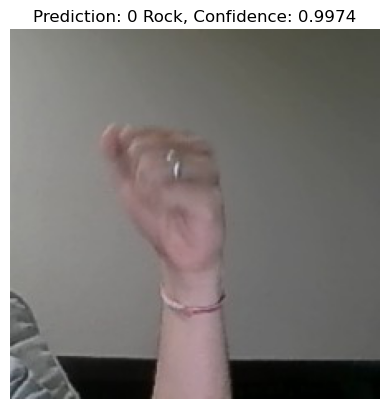

In [6]:
def prep_input(image_path):
    # Load the image
    image = Image.open(image_path).convert("RGB")

    # Resize and normalize the image
    size = (224, 224)
    image = ImageOps.fit(image, size, Image.Resampling.LANCZOS)
    image_array = np.asarray(image).astype(np.float32) / 127.5 - 1

    # Create the input array
    data = np.ndarray(shape=(1, 224, 224, 3), dtype=np.float32)
    data[0] = image_array
    return data

def predict(image_path):
    data = prep_input(image_path)
    prediction = model.predict(data)
    index = np.argmax(prediction)
    class_name = class_names[index]
    confidence_score = prediction[0][index]
    return class_name, confidence_score

# Test the prediction with an image from the dataset
image_path = r'C:\Users\Risha\OneDrive\Desktop\05\sample\Rock-samples\13.jpg'  
class_name, confidence_score = predict(image_path)

print(f"Class: {class_name}")
print(f"Confidence Score: {confidence_score:.4f}")

# Display the image using matplotlib
image = Image.open(image_path)
plt.imshow(image)
plt.title(f"Prediction: {class_name}, Confidence: {confidence_score:.4f}")
plt.axis('off')
plt.show()


## Conclusion

This notebook demonstrated how to use a model trained with Teachable Machine to classify images of rock, paper, and scissors. The methods shown include static image classification and real-time predictions using a webcam. 

For real-time predictions, run the `rock-paper-scissors-live.py` script.
